# Импорт библиотек

In [ ]:
%pip install statsforecast datasetsforecast plotly catboost -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 945.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 1.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

import random

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

from datasetsforecast.m4 import M4

from statsmodels.graphics.tsaplots import plot_acf

from statsforecast import StatsForecast
from statsforecast.models import  Naive, SeasonalNaive, AutoETS, AutoTheta

import sys

import catboost

import importlib

In [ ]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)


seed_everything()

# Загрузка данных и EDA

В работе используется датасет M4.

Для ускорения экспериментов и удобства анализа было выбрано 100 случайных временных рядов.

In [ ]:
data, *_ = M4.load(directory="data", group="Monthly")

In [ ]:
ids = np.random.choice(data['unique_id'].unique(), 100, replace=False)
data = data[data['unique_id'].isin(ids)]

In [ ]:
data.groupby('unique_id').size().describe()

,0
count,100.000000
mean,224.880000
std,140.401537
min,79.000000
25%,96.750000
50%,193.000000
75%,324.000000
max,840.000000


In [ ]:
fig = px.line(
    data,
    x="ds",
    y="y",
    color="unique_id"
)
fig.show()

Ряды имеют различную динамику и масштаб значений. Для некоторых рядов наблюдаются признаки сезонности.

In [ ]:
lengths = data.groupby('unique_id').size().reset_index(name='length')

fig = px.histogram(
    lengths,
    x="length",
    nbins=20,
    title="Распределение длин рядов"
)

fig.show()

Длины рядов варьируются, однако большинство рядов имеет сопоставимую продолжительность наблюдений.

In [ ]:
means = data.groupby('unique_id')['y'].mean().reset_index()

fig = px.histogram(
    means,
    x="y",
    nbins=50,
    title="Распределение средних значений рядов"
)

fig.show()

Распределение средних значений временных рядов подтверждает, что ряды имеют различный масштаб.

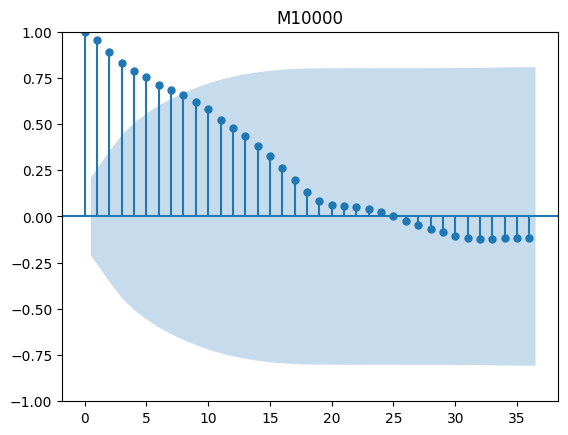

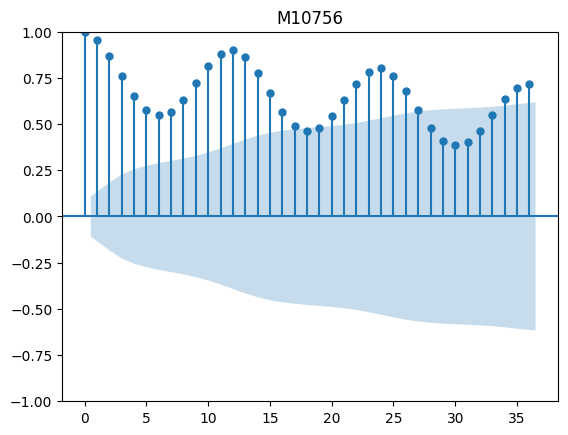

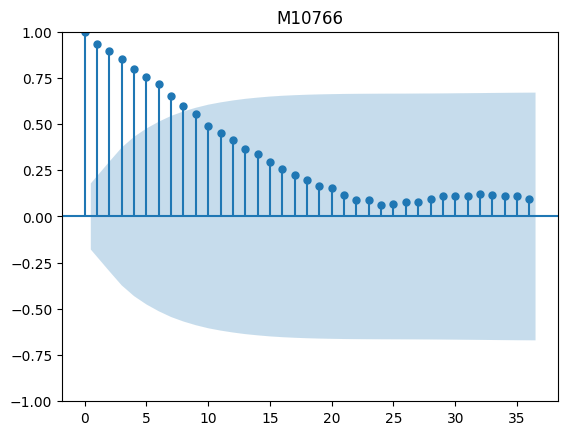

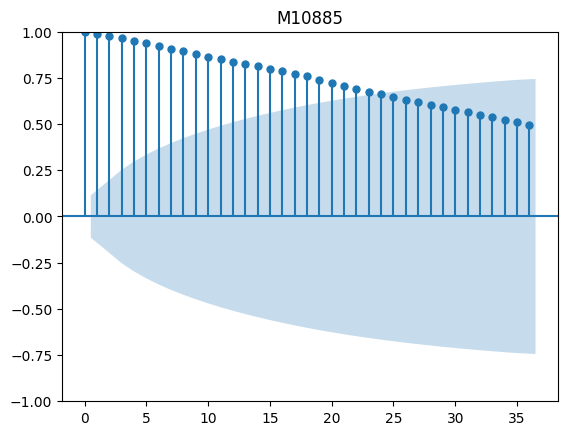

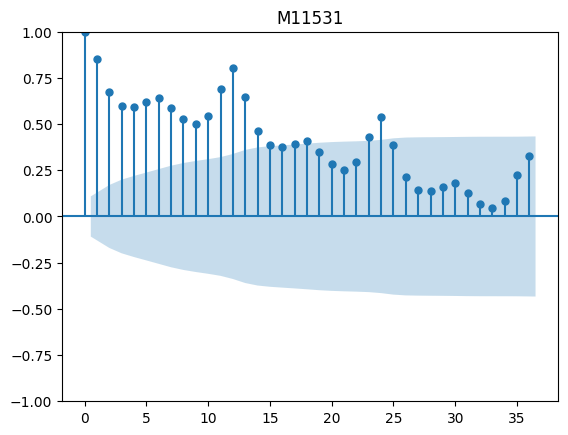

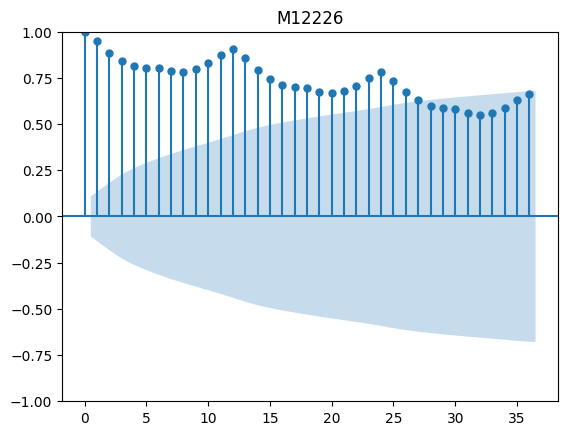

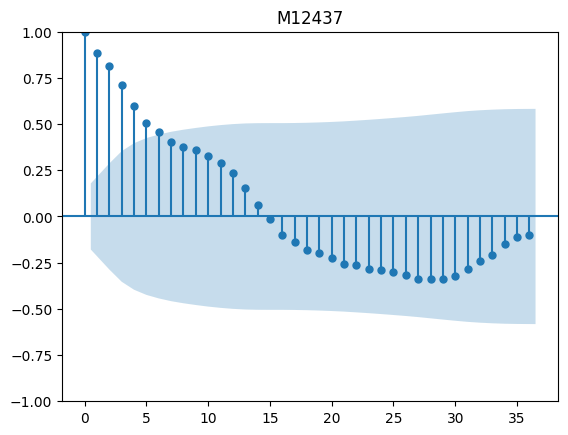

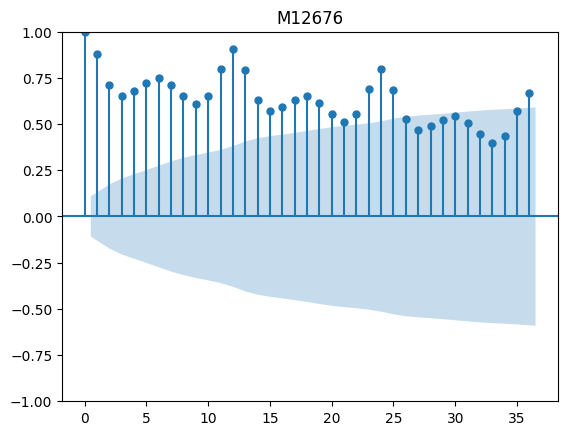

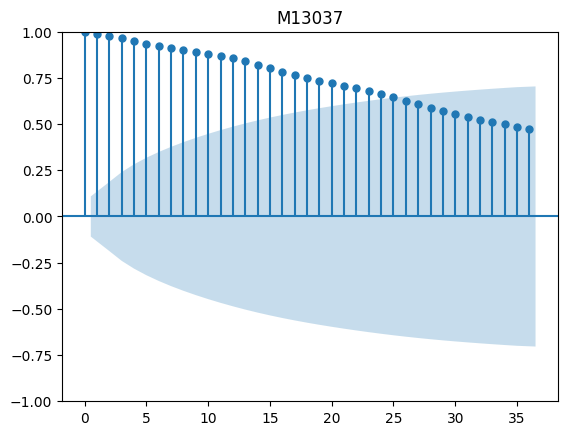

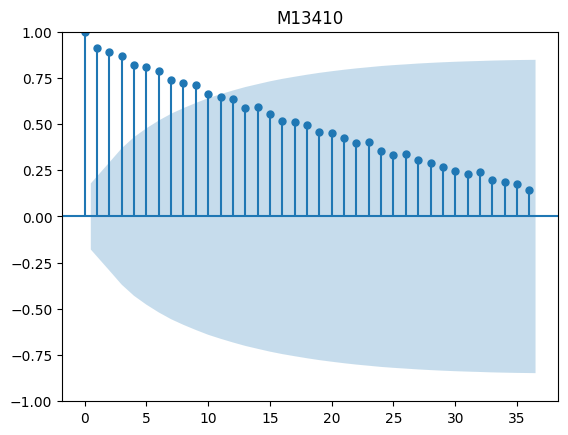

In [ ]:
sample_ids = data['unique_id'].unique()[:10]

for uid in sample_ids:
    ts = data[data.unique_id == uid]['y']
    plot_acf(ts, lags=36)
    plt.title(uid)
    plt.show()

По графикам автокорреляционной функции (ACF) для 10 случайно выбранных рядов видно, что наблюдения обладают значимой автокорреляцией. Для некоторых рядов наблюдаются выраженные пики на лагах 12 и 24 что указывает на наличие годовой сезонности.

# Построение бейзлайнов

Горизонт прогнозирования выбран равным 18. Это значение позволяет оценивать качество моделей на достаточно длинном промежутке времени и захватить период сезонности.

In [ ]:
HORIZON = 18
train = data.groupby('unique_id').apply(lambda x: x.iloc[:-HORIZON]).reset_index(drop=True)
test = data.groupby('unique_id').apply(lambda x: x.iloc[-HORIZON:]).reset_index(drop=True)

/tmp/ipykernel_29731/345730960.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train = data.groupby('unique_id').apply(lambda x: x.iloc[:-HORIZON]).reset_index(drop=True)
/tmp/ipykernel_29731/345730960.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test = data.groupby('unique_id').apply(lambda x: x.iloc[-HORIZON:]).reset_index(drop=True)


В качестве базовых моделей были использованы классические подходы к прогнозированию временных рядов.

In [ ]:
sf = StatsForecast(
    models=[
        AutoETS(season_length=12),
        AutoTheta(season_length=12),
        Naive(),
        SeasonalNaive(season_length=12),
    ],
    freq="ME",
    n_jobs=-1,
    verbose=True
)

preds = sf.forecast(df=train, h=HORIZON)

Forecast:   0%|          | 0/100 [Elapsed: 00:00]

In [ ]:
preds["ds"] = test["ds"].values

In [ ]:
def smape(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-8) -> float:
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred) + eps) / 2
    return 100 * np.mean(numerator / denominator)


def get_smape_metrics(
    test_df: pd.DataFrame,
    forecast_df: pd.DataFrame,
    id_col: str = "unique_id",
    time_col: str = "ds",
    target_col: str = "y",
) -> pd.DataFrame:
    test_with_preds = test_df.merge(
        forecast_df,
        on=[id_col, time_col],
        how="left",
    )

    model_names = [
        col for col in forecast_df.columns if col not in [id_col, time_col]
    ]

    smape_results = {}

    for model_name in model_names:
        smape_results[model_name] = {}

        # общая метрика по всем точкам
        smape_results[model_name]["all_points"] = smape(
            test_with_preds[target_col].values,
            test_with_preds[model_name].values,
        )

        # по каждому ряду отдельно
        series_scores = []
        for series_id in test_df[id_col].unique():
            test_series = test_with_preds[test_with_preds[id_col] == series_id]
            score = smape(
                test_series[target_col].values,
                test_series[model_name].values,
            )
            smape_results[model_name][series_id] = score
            series_scores.append(score)

        # среднее по рядам
        smape_results[model_name]["mean_by_series"] = np.mean(series_scores)

    return pd.DataFrame(smape_results)

In [ ]:
def mase(y_true: np.ndarray, y_pred: np.ndarray, y_train: np.ndarray, m: int = 1, eps: float = 1e-8) -> float:
    if len(y_train) <= m:
        return np.nan

    scale = np.mean(np.abs(y_train[m:] - y_train[:-m]))
    if scale < eps:
        return np.nan

    return np.mean(np.abs(y_true - y_pred)) / scale


def get_mase_metrics(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    forecast_df: pd.DataFrame,
    id_col: str = "unique_id",
    time_col: str = "ds",
    target_col: str = "y",
    seasonality: int = 12,
) -> pd.DataFrame:
    test_with_preds = test_df.merge(
        forecast_df,
        on=[id_col, time_col],
        how="left",
    )

    model_names = [
        col for col in forecast_df.columns if col not in [id_col, time_col]
    ]

    mase_results = {}

    for model_name in model_names:
        mase_results[model_name] = {}
        series_scores = []

        for series_id in test_df[id_col].unique():
            train_series = train_df[train_df[id_col] == series_id][target_col].values
            test_series = test_with_preds[test_with_preds[id_col] == series_id]

            score = mase(
                y_true=test_series[target_col].values,
                y_pred=test_series[model_name].values,
                y_train=train_series,
                m=seasonality,
            )
            mase_results[model_name][series_id] = score
            series_scores.append(score)

        mase_results[model_name]["mean_by_series"] = np.nanmean(series_scores)

    return pd.DataFrame(mase_results)

В качестве метрик качества были выбраны sMAPE и MASE.
Метрика sMAPE не зависит от масштаба временных рядов, что важно в данной задаче, поскольку рассматриваемые ряды имеют различный масштаб значений.
Метрика MASE используется как относительная метрика и позволяет сравнивать качество модели с наивным прогнозом вида $\hat{y}_t = y_{t-1}$

In [ ]:
smape_table = get_smape_metrics(test, preds)
mase_table = get_mase_metrics(train, test, preds, seasonality=12)

In [ ]:
baseline_metrics = pd.DataFrame({
    "sMAPE": smape_table.loc["mean_by_series"],
    "MASE": mase_table.loc["mean_by_series"],
}).reset_index().rename(columns={"index": "model"})

baseline_metrics = baseline_metrics.sort_values(["sMAPE", "MASE"])
baseline_metrics

,model,sMAPE,MASE
1,AutoTheta,15.552270,0.992397
0,AutoETS,15.818659,0.968117
2,Naive,17.754215,1.151728
3,SeasonalNaive,19.148227,1.244893


Среди бейзлайнов наилучшее качество показала модель AutoTheta, за ней следует AutoETS. Простая модель Naive демонстрирует более высокую ошибку, что ожидаемо. Модель SeasonalNaive показала наихудший результат, что может свидетельствовать о том, что сезонная структура в выбранных рядах выражена не слишком сильно или нестабильна.

In [ ]:
def plot_forecast(
    train_df,
    eval_df,
    series_id,
    models,
    id_col="unique_id",
    time_col="ds",
    target_col="y",
    title_prefix="Forecast"
):
    train_series = train_df[train_df[id_col] == series_id].copy()
    test_series = eval_df[eval_df[id_col] == series_id].copy()

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=train_series[time_col],
        y=train_series[target_col],
        mode="lines",
        name="Train"
    ))

    fig.add_trace(go.Scatter(
        x=test_series[time_col],
        y=test_series[target_col],
        mode="lines+markers",
        name="Test (real)"
    ))

    for model in models:
        fig.add_trace(go.Scatter(
            x=test_series[time_col],
            y=test_series[model],
            mode="lines+markers",
            name=model
        ))

    fig.update_layout(
        title=f"{title_prefix}: {series_id}",
        xaxis_title=time_col,
        yaxis_title=target_col,
        template="plotly_white",
        legend_title="Series",
        hovermode="x unified"
    )

    fig.show()

In [ ]:
plot_forecast(
    train_df=train,
    eval_df=test.merge(preds, on=["unique_id","ds"]),
    series_id="M10756",
    models=["AutoETS", "AutoTheta", "Naive", "SeasonalNaive"]
)

# Модель CatBoost Direct Mimo / Mimo

## model_horizon=6, history=24,  horizon=18

### Только обычные лаги

In [ ]:
!git clone https://github.com/Katiukh/TS_HW3.git

Cloning into 'TS_HW3'...
remote: Enumerating objects: 35, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 35 (delta 11), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (35/35), 481.30 KiB | 5.87 MiB/s, done.
Resolving deltas: 100% (11/11), done.


In [ ]:
!rm -rf /content/TS_HW3

In [ ]:
sys.path.append("/content/TS_HW3.git")

В качестве глобальной модели выбрана схема Direct-MIMO на CatBoost. Общий горизонт прогнозирования составляет 18 шагов, для первой конфигурации прогноз строится тремя независимыми блоками по 6 шагов. Такой подход уменьшает сложность задачи по сравнению с предсказанием всех 18 значений одной моделью и при этом не накапливает ошибки так, как рекурсивная стратегия.

In [ ]:
from modules import index_slicing, models, holdout, metrics

importlib.reload(index_slicing)
importlib.reload(models)
importlib.reload(holdout)
importlib.reload(metrics)

<module 'modules.metrics' from '/content/TS_HW3/modules/metrics.py'>

In [ ]:
from modules.holdout import run_holdout_experiment
from modules.feature_configs import lags_only_config

result = run_holdout_experiment(
    data=data,
    feature_config=lags_only_config,
    model_horizon=6,
    history=24,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result["sMAPE"])
print("MASE:", result["MASE"])

0:	learn: 7718.0881147	test: 9084.3795941	best: 9084.3795941 (0)	total: 1s	remaining: 3m 20s
100:	learn: 1488.8422418	test: 2077.8817749	best: 1998.1352182 (61)	total: 56.4s	remaining: 55.3s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1998.135218
bestIteration = 61

Shrink model to first 62 iterations.
0:	learn: 7790.2190133	test: 9026.5656599	best: 9026.5656599 (0)	total: 506ms	remaining: 1m 40s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 2476.071195
bestIteration = 36

Shrink model to first 37 iterations.
0:	learn: 7852.3087557	test: 9577.4312531	best: 9577.4312531 (0)	total: 473ms	remaining: 1m 34s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 4099.878919
bestIteration = 28

Shrink model to first 29 iterations.
sMAPE: 18.283403867657455
MASE: 1.5746276857804014


### Календарные признаки

In [ ]:
from modules.feature_configs import lags_calendar_config

result_calendar = run_holdout_experiment(
    data=data,
    feature_config=lags_calendar_config,
    model_horizon=6,
    history=24,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_calendar["sMAPE"])
print("MASE:", result_calendar["MASE"])

0:	learn: 7746.3535252	test: 9124.2913042	best: 9124.2913042 (0)	total: 6.17s	remaining: 20m 27s
100:	learn: 1529.3177151	test: 2037.8625752	best: 1961.1991300 (58)	total: 3m 37s	remaining: 3m 33s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1961.19913
bestIteration = 58

Shrink model to first 59 iterations.
0:	learn: 7797.2869736	test: 9069.8090820	best: 9069.8090820 (0)	total: 1.82s	remaining: 6m 1s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 2396.696729
bestIteration = 35

Shrink model to first 36 iterations.
0:	learn: 7852.9250734	test: 9530.1648021	best: 9530.1648021 (0)	total: 1.75s	remaining: 5m 47s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 3974.424501
bestIteration = 33

Shrink model to first 34 iterations.
sMAPE: 17.74802463735237
MASE: 1.4963242722106802


### Лаги + сезонные лаги

In [ ]:
from modules.feature_configs import lags_seasonal_config

result_seasonal = run_holdout_experiment(
    data=data,
    feature_config=lags_seasonal_config,
    model_horizon=6,
    history=24,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_seasonal["sMAPE"])
print("MASE:", result_seasonal["MASE"])

0:	learn: 7715.3190332	test: 9117.9323517	best: 9117.9323517 (0)	total: 499ms	remaining: 1m 39s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 2053.338506
bestIteration = 40

Shrink model to first 41 iterations.
0:	learn: 7777.4254782	test: 8995.1116361	best: 8995.1116361 (0)	total: 645ms	remaining: 2m 8s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 2282.480201
bestIteration = 33

Shrink model to first 34 iterations.
0:	learn: 7868.4363717	test: 9598.1981948	best: 9598.1981948 (0)	total: 411ms	remaining: 1m 21s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 3938.377649
bestIteration = 26

Shrink model to first 27 iterations.
sMAPE: 17.824225712907463
MASE: 1.5241657179896584


### Фурье признаки

In [ ]:
from modules.feature_configs import lags_fourier_config

result_fourier = run_holdout_experiment(
    data=data,
    feature_config=lags_fourier_config,
    model_horizon=6,
    history=24,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_fourier["sMAPE"])
print("MASE:", result_fourier["MASE"])

0:	learn: 7719.6783414	test: 9112.2342934	best: 9112.2342934 (0)	total: 530ms	remaining: 1m 45s
100:	learn: 1511.1223434	test: 1967.3789472	best: 1928.7700613 (63)	total: 60s	remaining: 58.8s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1928.770061
bestIteration = 63

Shrink model to first 64 iterations.
0:	learn: 7794.5967118	test: 9000.2750636	best: 9000.2750636 (0)	total: 552ms	remaining: 1m 49s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 2389.092409
bestIteration = 40

Shrink model to first 41 iterations.
0:	learn: 7852.8894204	test: 9537.4498526	best: 9537.4498526 (0)	total: 515ms	remaining: 1m 42s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 4052.399604
bestIteration = 27

Shrink model to first 28 iterations.
sMAPE: 18.102668851637947
MASE: 1.513816446218519


### Лаги + сезонные лаги + календарные признаки

In [ ]:
from modules.feature_configs import lags_seasonal_calendar_config

result_combo1 = run_holdout_experiment(
    data=data,
    feature_config=lags_seasonal_calendar_config,
    model_horizon=6,
    history=24,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_combo1["sMAPE"])
print("MASE:", result_combo1["MASE"])

0:	learn: 7721.7306784	test: 9080.2759916	best: 9080.2759916 (0)	total: 1.89s	remaining: 6m 15s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1903.659584
bestIteration = 45

Shrink model to first 46 iterations.
0:	learn: 7785.0338244	test: 9044.2719608	best: 9044.2719608 (0)	total: 1.79s	remaining: 5m 56s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 2288.029632
bestIteration = 38

Shrink model to first 39 iterations.
0:	learn: 7855.0856439	test: 9575.1718497	best: 9575.1718497 (0)	total: 1.65s	remaining: 5m 28s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 3910.840092
bestIteration = 35

Shrink model to first 36 iterations.
sMAPE: 17.400901977999315
MASE: 1.46718722472864


### Лаги + Фурье признаки + календарные признаки

In [ ]:
from modules.feature_configs import lags_fourier_calendar_config

result_combo2 = run_holdout_experiment(
    data=data,
    feature_config=lags_fourier_calendar_config,
    model_horizon=6,
    history=24,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_combo2["sMAPE"])
print("MASE:", result_combo2["MASE"])

0:	learn: 7731.6434093	test: 9065.3292390	best: 9065.3292390 (0)	total: 2.38s	remaining: 7m 53s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1993.242579
bestIteration = 43

Shrink model to first 44 iterations.
0:	learn: 7787.2237217	test: 9017.1097962	best: 9017.1097962 (0)	total: 1.88s	remaining: 6m 13s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 2360.262652
bestIteration = 37

Shrink model to first 38 iterations.
0:	learn: 7851.2285369	test: 9559.9726028	best: 9559.9726028 (0)	total: 2.9s	remaining: 9m 38s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 3881.620741
bestIteration = 42

Shrink model to first 43 iterations.
sMAPE: 17.791413835052285
MASE: 1.5254614684494663


### Сравнение всех результатов

In [ ]:
results = [
    ("lags_only", result["sMAPE"], result["MASE"]),
    ("lags_seasonal", result_seasonal["sMAPE"], result_seasonal["MASE"]),
    ("lags_calendar", result_calendar["sMAPE"], result_calendar["MASE"]),
    ("lags_fourier", result_fourier["sMAPE"], result_fourier["MASE"]),
    ("lags_seasonal_calendar", result_combo1["sMAPE"], result_combo1["MASE"]),
    ("lags_fourier_calendar", result_combo2["sMAPE"], result_combo2["MASE"]),
]

results_df = pd.DataFrame(results, columns=["features", "sMAPE", "MASE"])
results_df = results_df.sort_values("sMAPE").reset_index(drop=True)

results_df

,features,sMAPE,MASE
0,lags_seasonal_calendar,17.400902,1.467187
1,lags_calendar,17.748025,1.496324
2,lags_fourier_calendar,17.791414,1.525461
3,lags_seasonal,17.824226,1.524166
4,lags_fourier,18.102669,1.513816
5,lags_only,18.283404,1.574628


In [ ]:
eval_plot_df = result_seasonal["truth_df"].copy()

eval_plot_df = eval_plot_df.merge(
    result["pred_df"].rename(columns={"predicted_value": "lags_only"}),
    on=["unique_id", "ds"],
    how="left"
)

eval_plot_df = eval_plot_df.merge(
    result_seasonal["pred_df"].rename(columns={"predicted_value": "lags_seasonal"}),
    on=["unique_id", "ds"],
    how="left"
)

eval_plot_df = eval_plot_df.merge(
    result_calendar["pred_df"].rename(columns={"predicted_value": "lags_calendar"}),
    on=["unique_id", "ds"],
    how="left"
)

eval_plot_df = eval_plot_df.merge(
    result_fourier["pred_df"].rename(columns={"predicted_value": "lags_fourier"}),
    on=["unique_id", "ds"],
    how="left"
)

eval_plot_df = eval_plot_df.merge(
    result_combo1["pred_df"].rename(columns={"predicted_value": "lags_seasonal_calendar"}),
    on=["unique_id", "ds"],
    how="left"
)

eval_plot_df = eval_plot_df.merge(
    result_combo2["pred_df"].rename(columns={"predicted_value": "lags_fourier_calendar"}),
    on=["unique_id", "ds"],
    how="left"
)

In [ ]:
plot_forecast(
    train_df=result_seasonal["train_df"],
    eval_df=eval_plot_df,
    series_id="M10756",
    models=[
        "lags_only",
        "lags_seasonal",
        "lags_calendar",
        "lags_fourier",
        "lags_seasonal_calendar",
        "lags_fourier_calendar"
    ],
    id_col="unique_id",
    time_col="ds",
    target_col="y",
    title_prefix="Forecast comparison"
)

В эксперименте с фиксированными параметрами model_horizon = 6, history = 24 и horizon = 18 наилучшее качество показала модель с лаговыми, сезонными и календарными признаками (sMAPE ≈ 17.40, MASE ≈ 1.47). Использование только лагов дало худший результат, что подтверждает недостаточность учета лишь локальной динамики. Добавление сезонных лагов улучшает качество, а календарные признаки дают небольшой дополнительный эффект. При этом Фурье-признаки не привели к улучшению и оказались избыточными.

## Другие горизонты/лаги для lags_only_config

In [ ]:
from modules.holdout import run_holdout_experiment
from modules.feature_configs import lags_only_config

result_3 = run_holdout_experiment(
    data=data,
    feature_config=lags_only_config,
    model_horizon=3,
    history=24,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_3["sMAPE"])
print("MASE:", result_3["MASE"])

0:	learn: 5451.1956920	test: 6351.4069758	best: 6351.4069758 (0)	total: 189ms	remaining: 37.6s
100:	learn: 948.9455325	test: 1215.4480947	best: 1168.0014763 (55)	total: 10.1s	remaining: 9.87s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1168.001476
bestIteration = 55

Shrink model to first 56 iterations.
0:	learn: 5479.1844045	test: 6524.3229866	best: 6524.3229866 (0)	total: 102ms	remaining: 20.2s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1594.760012
bestIteration = 41

Shrink model to first 42 iterations.
0:	learn: 5501.4629781	test: 6281.4498279	best: 6281.4498279 (0)	total: 93.3ms	remaining: 18.6s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1746.043266
bestIteration = 35

Shrink model to first 36 iterations.
0:	learn: 5530.3483655	test: 6483.6384001	best: 6483.6384001 (0)	total: 93.8ms	remaining: 18.7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1763.939546
bestIteration = 37

Shrink model to fi

In [ ]:
from modules.holdout import run_holdout_experiment
from modules.feature_configs import lags_only_config

result_3 = run_holdout_experiment(
    data=data,
    feature_config=lags_only_config,
    model_horizon=1,
    history=36,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_3["sMAPE"])
print("MASE:", result_3["MASE"])

0:	learn: 3187.4266186	test: 3664.6002145	best: 3664.6002145 (0)	total: 23.8ms	remaining: 4.74s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 740.6843612
bestIteration = 39

Shrink model to first 40 iterations.
0:	learn: 3184.5283663	test: 3595.4756926	best: 3595.4756926 (0)	total: 23.7ms	remaining: 4.71s
100:	learn: 524.7322638	test: 767.3873763	best: 741.0288977 (68)	total: 2.06s	remaining: 2.02s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 741.0288977
bestIteration = 68

Shrink model to first 69 iterations.
0:	learn: 3192.9085808	test: 3732.4649916	best: 3732.4649916 (0)	total: 22.7ms	remaining: 4.51s
100:	learn: 559.3458146	test: 682.6293787	best: 682.6293787 (100)	total: 2.04s	remaining: 2s
199:	learn: 470.1973252	test: 669.9264006	best: 667.6348806 (167)	total: 5.3s	remaining: 0us

bestTest = 667.6348806
bestIteration = 167

Shrink model to first 168 iterations.
0:	learn: 3203.2984567	test: 3723.7175230	best: 3723.7175230 (0)	total: 33.6ms

In [ ]:
from modules.holdout import run_holdout_experiment
from modules.feature_configs import lags_only_config

result_3 = run_holdout_experiment(
    data=data,
    feature_config=lags_only_config,
    model_horizon=1,
    history=12,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_3["sMAPE"])
print("MASE:", result_3["MASE"])

0:	learn: 3143.3196937	test: 3708.1111856	best: 3708.1111856 (0)	total: 15.2ms	remaining: 3.03s
100:	learn: 496.7567935	test: 726.2786695	best: 712.1424955 (57)	total: 1.35s	remaining: 1.33s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 712.1424955
bestIteration = 57

Shrink model to first 58 iterations.
0:	learn: 3142.0584451	test: 3592.2530580	best: 3592.2530580 (0)	total: 14.6ms	remaining: 2.91s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 587.0602331
bestIteration = 42

Shrink model to first 43 iterations.
0:	learn: 3144.0973498	test: 3719.0996089	best: 3719.0996089 (0)	total: 16.4ms	remaining: 3.27s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 536.6540813
bestIteration = 49

Shrink model to first 50 iterations.
0:	learn: 3148.0736409	test: 3743.9490941	best: 3743.9490941 (0)	total: 16ms	remaining: 3.18s
100:	learn: 643.6436060	test: 802.4835478	best: 775.1616985 (67)	total: 1.34s	remaining: 1.31s
Stopped by overfitting 

In [ ]:
from modules.holdout import run_holdout_experiment
from modules.feature_configs import lags_only_config

result_3 = run_holdout_experiment(
    data=data,
    feature_config=lags_only_config,
    model_horizon=6,
    history=12,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_3["sMAPE"])
print("MASE:", result_3["MASE"])

0:	learn: 7698.7860653	test: 9165.9501638	best: 9165.9501638 (0)	total: 500ms	remaining: 1m 39s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1865.640724
bestIteration = 43

Shrink model to first 44 iterations.
0:	learn: 7712.6704450	test: 9053.4037398	best: 9053.4037398 (0)	total: 464ms	remaining: 1m 32s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 2292.132722
bestIteration = 33

Shrink model to first 34 iterations.
0:	learn: 7763.4730191	test: 9560.5446274	best: 9560.5446274 (0)	total: 450ms	remaining: 1m 29s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 3944.425102
bestIteration = 32

Shrink model to first 33 iterations.
sMAPE: 17.35155485490989
MASE: 1.499546104022302


In [ ]:
from modules.holdout import run_holdout_experiment
from modules.feature_configs import lags_only_config

result_3 = run_holdout_experiment(
    data=data,
    feature_config=lags_only_config,
    model_horizon=2,
    history=36,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_3["sMAPE"])
print("MASE:", result_3["MASE"])

0:	learn: 4501.3505226	test: 5120.8296932	best: 5120.8296932 (0)	total: 52.8ms	remaining: 10.5s
100:	learn: 728.9205084	test: 885.8961814	best: 885.8961814 (100)	total: 6.61s	remaining: 6.48s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 873.8370032
bestIteration = 126

Shrink model to first 127 iterations.
0:	learn: 4523.2532118	test: 5231.7339228	best: 5231.7339228 (0)	total: 51.5ms	remaining: 10.2s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1014.527183
bestIteration = 49

Shrink model to first 50 iterations.
0:	learn: 4539.0451544	test: 5316.9239494	best: 5316.9239494 (0)	total: 50.3ms	remaining: 10s
100:	learn: 909.5089769	test: 1423.3789744	best: 1370.7564766 (55)	total: 4.83s	remaining: 4.73s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1370.756477
bestIteration = 55

Shrink model to first 56 iterations.
0:	learn: 4560.6009923	test: 5074.2636671	best: 5074.2636671 (0)	total: 73.5ms	remaining: 14.6s
Stopped by overfit

In [ ]:
from modules.holdout import run_holdout_experiment
from modules.feature_configs import lags_only_config

result_3 = run_holdout_experiment(
    data=data,
    feature_config=lags_only_config,
    model_horizon=2,
    history=12,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_3["sMAPE"])
print("MASE:", result_3["MASE"])

0:	learn: 4443.1341028	test: 5175.8857312	best: 5175.8857312 (0)	total: 40.1ms	remaining: 7.98s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 939.0654045
bestIteration = 37

Shrink model to first 38 iterations.
0:	learn: 4449.8637383	test: 5305.6990716	best: 5305.6990716 (0)	total: 41.2ms	remaining: 8.2s
100:	learn: 891.2858889	test: 1043.5816445	best: 1030.4496472 (60)	total: 3.48s	remaining: 3.41s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1030.449647
bestIteration = 60

Shrink model to first 61 iterations.
0:	learn: 4443.6220485	test: 5322.7397295	best: 5322.7397295 (0)	total: 41.9ms	remaining: 8.35s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1250.843285
bestIteration = 42

Shrink model to first 43 iterations.
0:	learn: 4449.2460954	test: 5088.9793240	best: 5088.9793240 (0)	total: 79.1ms	remaining: 15.7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1355.806842
bestIteration = 32

Shrink model to f

In [ ]:
from modules.holdout import run_holdout_experiment
from modules.feature_configs import lags_only_config

result_3 = run_holdout_experiment(
    data=data,
    feature_config=lags_only_config,
    model_horizon=3,
    history=6,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_3["sMAPE"])
print("MASE:", result_3["MASE"])

0:	learn: 5422.8474249	test: 6341.3427959	best: 6341.3427959 (0)	total: 83.5ms	remaining: 16.6s
100:	learn: 1001.5187460	test: 1258.6116767	best: 1170.2623936 (56)	total: 9.6s	remaining: 9.41s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1170.262394
bestIteration = 56

Shrink model to first 57 iterations.
0:	learn: 5446.8533254	test: 6542.3810207	best: 6542.3810207 (0)	total: 82.2ms	remaining: 16.4s
100:	learn: 1236.2369051	test: 1578.0561685	best: 1507.5709903 (50)	total: 9.11s	remaining: 8.93s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1507.57099
bestIteration = 50

Shrink model to first 51 iterations.
0:	learn: 5450.0766092	test: 6275.0163486	best: 6275.0163486 (0)	total: 173ms	remaining: 34.4s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1563.900073
bestIteration = 37

Shrink model to first 38 iterations.
0:	learn: 5455.5428383	test: 6501.6853186	best: 6501.6853186 (0)	total: 81.8ms	remaining: 16.3s
Stopped by overfit

In [ ]:
from modules.holdout import run_holdout_experiment
from modules.feature_configs import lags_only_config

result_3 = run_holdout_experiment(
    data=data,
    feature_config=lags_only_config,
    model_horizon=1,
    history=6,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_3["sMAPE"])
print("MASE:", result_3["MASE"])

0:	learn: 3129.7955299	test: 3691.7087553	best: 3691.7087553 (0)	total: 13.2ms	remaining: 2.62s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 768.5436455
bestIteration = 31

Shrink model to first 32 iterations.
0:	learn: 3136.0618175	test: 3617.0773875	best: 3617.0773875 (0)	total: 11.2ms	remaining: 2.23s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 767.88706
bestIteration = 40

Shrink model to first 41 iterations.
0:	learn: 3146.6294220	test: 3740.9316755	best: 3740.9316755 (0)	total: 12ms	remaining: 2.38s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 533.2562766
bestIteration = 46

Shrink model to first 47 iterations.
0:	learn: 3142.6948662	test: 3740.9675462	best: 3740.9675462 (0)	total: 12.3ms	remaining: 2.44s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 797.9919963
bestIteration = 40

Shrink model to first 41 iterations.
0:	learn: 3147.0364787	test: 3769.3661992	best: 3769.3661992 (0)	total: 12ms	rem

In [ ]:
from modules.holdout import run_holdout_experiment
from modules.feature_configs import lags_only_config

result_3 = run_holdout_experiment(
    data=data,
    feature_config=lags_only_config,
    model_horizon=1,
    history=3,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_3["sMAPE"])
print("MASE:", result_3["MASE"])

0:	learn: 3131.8876006	test: 3695.3146280	best: 3695.3146280 (0)	total: 11.4ms	remaining: 2.27s
100:	learn: 543.8655879	test: 712.9049239	best: 707.3185497 (50)	total: 1.03s	remaining: 1s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 707.3185497
bestIteration = 50

Shrink model to first 51 iterations.
0:	learn: 3133.8854463	test: 3611.0099501	best: 3611.0099501 (0)	total: 10.9ms	remaining: 2.18s
100:	learn: 600.6389332	test: 684.3889135	best: 650.0538872 (50)	total: 1.01s	remaining: 993ms
Stopped by overfitting detector  (50 iterations wait)

bestTest = 650.0538872
bestIteration = 50

Shrink model to first 51 iterations.
0:	learn: 3136.1274229	test: 3717.0406550	best: 3717.0406550 (0)	total: 10.1ms	remaining: 2.02s
100:	learn: 642.1797139	test: 571.6309856	best: 558.2038739 (69)	total: 1.01s	remaining: 992ms
Stopped by overfitting detector  (50 iterations wait)

bestTest = 558.2038739
bestIteration = 69

Shrink model to first 70 iterations.
0:	learn: 3143.0665835	te

In [ ]:
from modules.holdout import run_holdout_experiment
from modules.feature_configs import lags_only_config

result_3 = run_holdout_experiment(
    data=data,
    feature_config=lags_only_config,
    model_horizon=2,
    history=4,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_3["sMAPE"])
print("MASE:", result_3["MASE"])

0:	learn: 4432.2633617	test: 5163.0990726	best: 5163.0990726 (0)	total: 31.3ms	remaining: 6.22s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1011.883045
bestIteration = 28

Shrink model to first 29 iterations.
0:	learn: 4436.6377207	test: 5299.9303018	best: 5299.9303018 (0)	total: 30.6ms	remaining: 6.1s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 912.8271318
bestIteration = 44

Shrink model to first 45 iterations.
0:	learn: 4444.1790972	test: 5311.0147436	best: 5311.0147436 (0)	total: 32ms	remaining: 6.36s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1262.890601
bestIteration = 44

Shrink model to first 45 iterations.
0:	learn: 4444.9586070	test: 5057.8865138	best: 5057.8865138 (0)	total: 29.3ms	remaining: 5.83s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1384.788401
bestIteration = 31

Shrink model to first 32 iterations.
0:	learn: 4457.0143035	test: 5245.0612732	best: 5245.0612732 (0)	total: 31.8ms	

In [ ]:
results_experiment = pd.DataFrame([
    {"model_horizon": 3, "history": 24, "sMAPE": 17.94908966265101, "MASE": 1.4551469329440057},
    {"model_horizon": 1, "history": 36, "sMAPE": 17.779533820084463, "MASE": 1.4120098797540621},
    {"model_horizon": 1, "history": 12, "sMAPE": 17.23246517910742, "MASE": 1.4340839546977038},
    {"model_horizon": 6, "history": 12, "sMAPE": 17.35155485490989, "MASE": 1.499546104022302},
    {"model_horizon": 2, "history": 36, "sMAPE": 17.66870750693668, "MASE": 1.4371473246310467},
    {"model_horizon": 2, "history": 12, "sMAPE": 17.488184262828888, "MASE": 1.4241862668771743},
    {"model_horizon": 3, "history": 6, "sMAPE": 17.36875067363822, "MASE": 1.421912244483293},
    {"model_horizon": 1, "history": 6, "sMAPE": 17.382981680637798, "MASE": 1.4166966759422603},
    {"model_horizon": 1, "history": 3, "sMAPE": 17.59109318120792, "MASE": 1.4502403938549486},
    {"model_horizon": 2, "history": 4, "sMAPE": 17.65953774788054, "MASE": 1.4679589758578673},
])

results_experiment

,model_horizon,history,sMAPE,MASE
0,3,24,17.949090,1.455147
1,1,36,17.779534,1.412010
2,1,12,17.232465,1.434084
3,6,12,17.351555,1.499546
4,2,36,17.668708,1.437147
5,2,12,17.488184,1.424186
6,3,6,17.368751,1.421912
7,1,6,17.382982,1.416697
8,1,3,17.591093,1.450240
9,2,4,17.659538,1.467959


In [ ]:
pivot_smape = results_experiment.pivot(
    index="history",
    columns="model_horizon",
    values="sMAPE"
)

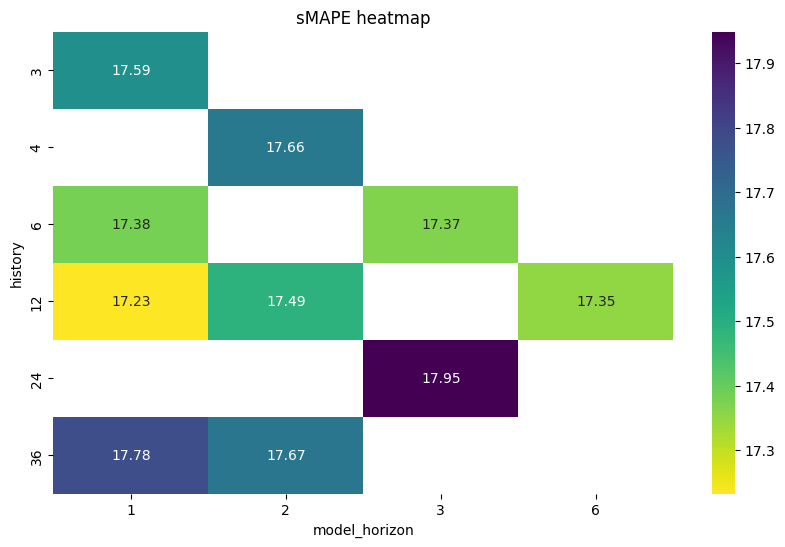

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_smape, annot=True, fmt=".2f", cmap="viridis_r")
plt.title("sMAPE heatmap")
plt.xlabel("model_horizon")
plt.ylabel("history")
plt.show()

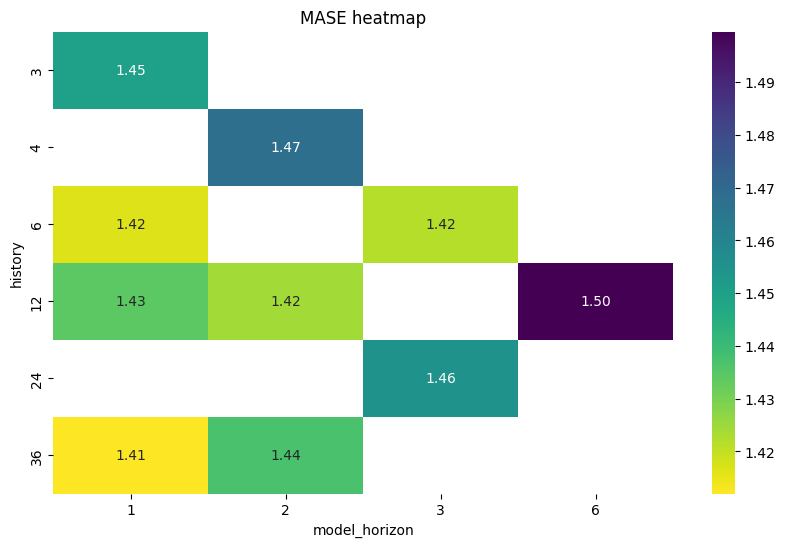

In [ ]:
pivot_mase = results_experiment.pivot(
    index="history",
    columns="model_horizon",
    values="MASE"
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_mase, annot=True, fmt=".2f", cmap="viridis_r")
plt.title("MASE heatmap")
plt.xlabel("model_horizon")
plt.ylabel("history")
plt.show()

В эксперименте с использованием только лаговых признаков было установлено, что качество модели существенно зависит от параметров history и model_horizon. Наилучшие результаты достигаются при небольшом горизонте модели (model_horizon = 1) и умеренной или увеличенной длине истории (history = 12–36), где достигаются минимальные значения метрик (sMAPE ≈ 17.23, MASE ≈ 1.41). Увеличение model_horizon приводит к ухудшению качества, так как задача прогнозирования становится сложнее. В целом использование только лагов дает более слабые результаты по сравнению с конфигурациями, учитывающими сезонность, что указывает на недостаточность учета исключительно локальной динамики ряда.

## Сезонные лаги с оптимальными model_horizon и history

Посмотрим на оптимальные model_horizon и history для обычных лагов и сезонных.

In [77]:
experiments_lags_seasonal = [
    {"model_horizon": 1, "history": 24},
    {"model_horizon": 2, "history": 24},
    {"model_horizon": 3, "history": 24},
    {"model_horizon": 1, "history": 36},
    {"model_horizon": 2, "history": 36},
    {"model_horizon": 3, "history": 36},
    {"model_horizon": 1, "history": 48}

]
results_lags_seasonal = []
artifacts_lags_seasonal = {}

for cfg in experiments_lags_seasonal:
    model_horizon = cfg["model_horizon"]
    history = cfg["history"]

    print(f"Running: history={history}, model_horizon={model_horizon}")

    res = run_holdout_experiment(
        data=data,
        feature_config=lags_seasonal_config,
        model_horizon=model_horizon,
        history=history,
        horizon=18,
        freq="M",
        id_col="unique_id",
        timestamp_col="ds",
        value_col="y",
        seasonality=12,
    )

    results_lags_seasonal.append({
        "feature_set": "lags_seasonal_12",
        "model_horizon": model_horizon,
        "history": history,
        "sMAPE": res["sMAPE"],
        "MASE": res["MASE"],
    })

    artifacts_lags_seasonal[(model_horizon, history)] = res
results_lags_seasonal_df = pd.DataFrame(results_lags_seasonal)
results_lags_seasonal_df = results_lags_seasonal_df.sort_values(
    ["MASE", "sMAPE"]
).reset_index(drop=True)

results_lags_seasonal_df

Running: history=24, model_horizon=1
0:	learn: 3146.1814126	test: 3690.7750638	best: 3690.7750638 (0)	total: 13.2ms	remaining: 2.63s
100:	learn: 477.4598173	test: 1006.2456484	best: 912.2000541 (51)	total: 1.14s	remaining: 1.12s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 912.2000541
bestIteration = 51

Shrink model to first 52 iterations.
0:	learn: 3151.7511968	test: 3610.0325865	best: 3610.0325865 (0)	total: 12.9ms	remaining: 2.57s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 696.2855117
bestIteration = 31

Shrink model to first 32 iterations.
0:	learn: 3156.9835753	test: 3745.3942674	best: 3745.3942674 (0)	total: 26.2ms	remaining: 5.21s
100:	learn: 583.5166768	test: 597.0006553	best: 574.2064544 (79)	total: 1.88s	remaining: 1.84s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 574.2064544
bestIteration = 79

Shrink model to first 80 iterations.
0:	learn: 3156.0990358	test: 3744.6607407	best: 3744.6607407 (0)	total: 13ms	re

,feature_set,model_horizon,history,sMAPE,MASE
0,lags_seasonal_12,1,36,16.947257,1.355594
1,lags_seasonal_12,3,36,17.014374,1.369495
2,lags_seasonal_12,2,36,17.174068,1.382400
3,lags_seasonal_12,2,24,17.278045,1.416869
4,lags_seasonal_12,1,48,17.267058,1.423636
5,lags_seasonal_12,1,24,17.403090,1.455209
6,lags_seasonal_12,3,24,17.541690,1.485790


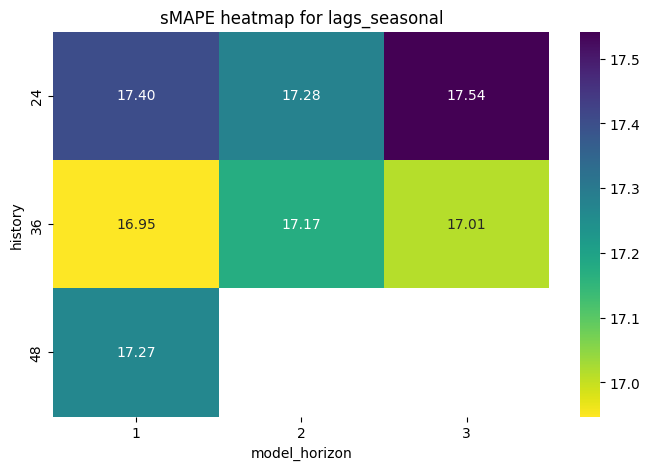

In [92]:
pivot_smape_seasonal = results_lags_seasonal_df.pivot(
    index="history",
    columns="model_horizon",
    values="sMAPE"
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_smape_seasonal, annot=True, fmt=".2f", cmap="viridis_r")
plt.title("sMAPE heatmap for lags_seasonal")
plt.xlabel("model_horizon")
plt.ylabel("history")
plt.show()

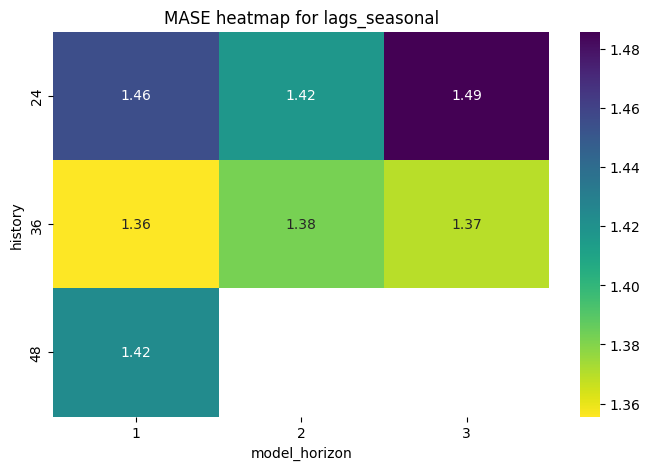

In [93]:
pivot_mase_seasonal = results_lags_seasonal_df.pivot(
    index="history",
    columns="model_horizon",
    values="MASE"
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_mase_seasonal, annot=True, fmt=".2f", cmap="viridis_r")
plt.title("MASE heatmap for lags_seasonal")
plt.xlabel("model_horizon")
plt.ylabel("history")
plt.show()

При добавлении сезонных лагов наблюдается заметное улучшение качества модели по сравнению с использованием только лагов. Наилучшие результаты достигаются при параметрах history = 36 и model_horizon = 1, где достигаются минимальные значения метрик (sMAPE ≈ 16.95, MASE ≈ 1.36). Это подтверждает, что учет сезонной структуры данных существенно повышает качество прогноза. При увеличении model_horizon качество ухудшается, что связано с усложнением задачи многократного прогнозирования.


## Сезонные лаги и календарные признаки с оптимальными model_horizon и history

In [80]:
experiments_lags_seasonal_calendar = [
    {"model_horizon": 1, "history": 24},
    {"model_horizon": 2, "history": 24},
    {"model_horizon": 3, "history": 24},
    {"model_horizon": 1, "history": 36},
    {"model_horizon": 2, "history": 36},
    {"model_horizon": 3, "history": 36},
    {"model_horizon": 1, "history": 48}
]

results_lags_seasonal_calendar = []
artifacts_lags_seasonal_calendar = {}

for cfg in experiments_lags_seasonal_calendar:
    model_horizon = cfg["model_horizon"]
    history = cfg["history"]

    print(f"Running: history={history}, model_horizon={model_horizon}")

    res = run_holdout_experiment(
        data=data,
        feature_config=lags_seasonal_calendar_config,
        model_horizon=model_horizon,
        history=history,
        horizon=18,
        freq="M",
        id_col="unique_id",
        timestamp_col="ds",
        value_col="y",
        seasonality=12,
    )

    results_lags_seasonal_calendar.append({
        "feature_set": "lags_seasonal_calendar_12",
        "model_horizon": model_horizon,
        "history": history,
        "sMAPE": res["sMAPE"],
        "MASE": res["MASE"],
    })

    artifacts_lags_seasonal_calendar[(model_horizon, history)] = res

results_lags_seasonal_calendar_df = pd.DataFrame(results_lags_seasonal_calendar)
results_lags_seasonal_calendar_df = results_lags_seasonal_calendar_df.sort_values(
    ["MASE", "sMAPE"]
).reset_index(drop=True)

results_lags_seasonal_calendar_df

Running: history=24, model_horizon=1
0:	learn: 3142.3515018	test: 3674.4402906	best: 3674.4402906 (0)	total: 30.2ms	remaining: 6.01s
100:	learn: 493.1775224	test: 838.0740246	best: 795.2228534 (53)	total: 3.7s	remaining: 3.63s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 795.2228534
bestIteration = 53

Shrink model to first 54 iterations.
0:	learn: 3153.5907877	test: 3615.6602120	best: 3615.6602120 (0)	total: 25.7ms	remaining: 5.12s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 661.0445767
bestIteration = 36

Shrink model to first 37 iterations.
0:	learn: 3161.4881450	test: 3756.5289962	best: 3756.5289962 (0)	total: 25.3ms	remaining: 5.03s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 569.1867894
bestIteration = 42

Shrink model to first 43 iterations.
0:	learn: 3154.1748582	test: 3724.7610198	best: 3724.7610198 (0)	total: 24.7ms	remaining: 4.92s
100:	learn: 621.8947850	test: 876.5876230	best: 842.5136429 (50)	total: 2.17s	re

,feature_set,model_horizon,history,sMAPE,MASE
0,lags_seasonal_calendar_12,1,48,17.113123,1.367554
1,lags_seasonal_calendar_12,1,36,17.398171,1.435583
2,lags_seasonal_calendar_12,3,36,17.110225,1.436833
3,lags_seasonal_calendar_12,2,36,17.235824,1.442578
4,lags_seasonal_calendar_12,1,24,17.334607,1.443663
5,lags_seasonal_calendar_12,3,24,17.398266,1.474852
6,lags_seasonal_calendar_12,2,24,17.382746,1.482357


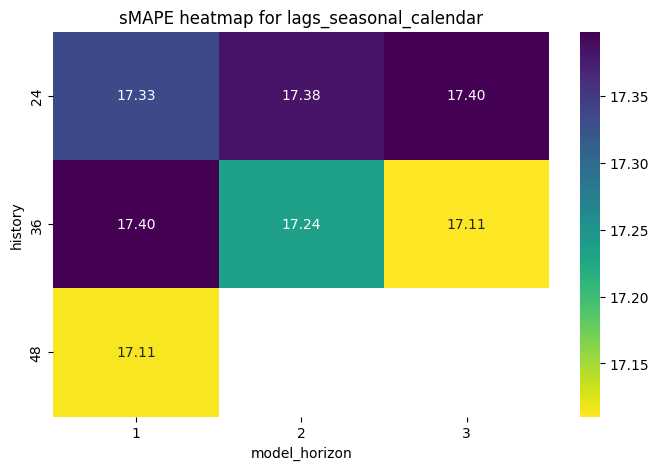

In [94]:
pivot_smape_seasonal_calendar = results_lags_seasonal_calendar_df.pivot(
    index="history",
    columns="model_horizon",
    values="sMAPE"
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_smape_seasonal_calendar, annot=True, fmt=".2f", cmap="viridis_r")
plt.title("sMAPE heatmap for lags_seasonal_calendar")
plt.xlabel("model_horizon")
plt.ylabel("history")
plt.show()

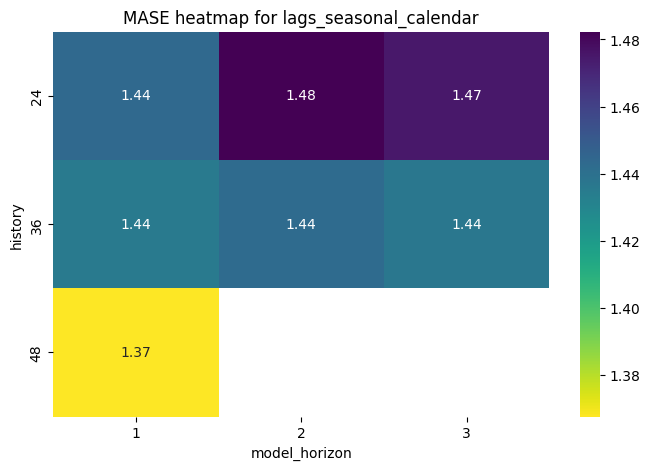

In [95]:
pivot_mase_seasonal_calendar = results_lags_seasonal_calendar_df.pivot(
    index="history",
    columns="model_horizon",
    values="MASE"
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_mase_seasonal_calendar, annot=True, fmt=".2f", cmap="viridis_r")
plt.title("MASE heatmap for lags_seasonal_calendar")
plt.xlabel("model_horizon")
plt.ylabel("history")
plt.show()

Добавление календарных признаков к сезонным лагам не привело к существенному улучшению качества модели. В лучшей конфигурации (history = 48, model_horizon = 1) достигаются значения sMAPE ≈ 17.11 и MASE ≈ 1.37, что сопоставимо, но в целом хуже, чем при использовании только сезонных лагов. При других параметрах наблюдается даже некоторое ухудшение метрик, особенно при увеличении горизонта модели. Это указывает на то, что календарные признаки в данном случае не добавляют новой полезной информации и могут приводить к усложнению модели без выигрыша в качестве.

## Визуализация прогнозов лучшей модели по MASE и sMAPE

Посмотрим на предскзаания модели лучшей по обеим метрикам

In [88]:
from modules.holdout import run_holdout_experiment
from modules.feature_configs import lags_only_config

result_best_MASE = run_holdout_experiment(
    data=train,
    feature_config=lags_seasonal_config,
    model_horizon=1,
    history=36,
    horizon=18,
    freq="M",
    id_col="unique_id",
    timestamp_col="ds",
    value_col="y",
    seasonality=12,
)

print("sMAPE:", result_best_MASE["sMAPE"])
print("MASE:", result_best_MASE["MASE"])

0:	learn: 3137.1283129	test: 3476.6670297	best: 3476.6670297 (0)	total: 19.8ms	remaining: 3.94s
100:	learn: 427.8050455	test: 741.1269882	best: 720.0166771 (52)	total: 1.02s	remaining: 1s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 720.0166771
bestIteration = 52

Shrink model to first 53 iterations.
0:	learn: 3136.4946835	test: 3557.1942164	best: 3557.1942164 (0)	total: 10.4ms	remaining: 2.07s
100:	learn: 471.4847100	test: 756.5519614	best: 739.5979656 (52)	total: 996ms	remaining: 976ms
Stopped by overfitting detector  (50 iterations wait)

bestTest = 739.5979656
bestIteration = 52

Shrink model to first 53 iterations.
0:	learn: 3142.1125415	test: 3588.9303347	best: 3588.9303347 (0)	total: 10.2ms	remaining: 2.03s
100:	learn: 517.6462475	test: 733.9038933	best: 727.3397377 (74)	total: 1.01s	remaining: 989ms
Stopped by overfitting detector  (50 iterations wait)

bestTest = 727.3397377
bestIteration = 74

Shrink model to first 75 iterations.
0:	learn: 3145.9420612	te

In [89]:
plot_forecast(
    train_df= result_best_MASE["train_df"],
    eval_df= result_best_MASE["merged_predictions"],
    series_id="M10756",
    models=["predicted_value"],
    id_col="unique_id",
    time_col="ds",
    target_col="y",
    title_prefix="Best model forecast"
)

In [90]:
plot_forecast(
    train_df=result_best_MASE["train_df"],
    eval_df=result_best_MASE["merged_predictions"],
    series_id="M4556",
    models=["predicted_value"],
    id_col="unique_id",
    time_col="ds",
    target_col="y",
    title_prefix="Best model forecast"
)

In [91]:
plot_forecast(
    train_df=result_best_MASE["train_df"],
    eval_df=result_best_MASE["merged_predictions"],
    series_id="M41162",
    models=["predicted_value"],
    id_col="unique_id",
    time_col="ds",
    target_col="y",
    title_prefix="Best model forecast"
)

На визуализации прогнозов для различных рядов видно, что качество модели существенно варьируется в зависимости от структуры ряда.

Для части рядов модель хорошо улавливает общий уровень и динамику, обеспечивая близкие к реальным значениям прогнозы. Однако в более сложных случаях наблюдается сглаживание предсказаний: модель не воспроизводит локальные пики и спады. Классические модели справляются с сезонностью гораздо лучше.

Особенно заметно ухудшение качества на рядах с резкими выбросами, которые модель не способна предсказать на основе лаговых признаков.

# Общий вывод

В ходе экспериментов было установлено, что наилучшие результаты среди ML-подходов достигаются при использовании сезонных лагов. Лучшей конфигурацией ML-модели оказался вариант с сезонными лагами при history = 36 и model_horizon = 1, где были получены значения sMAPE ≈ 16.95 и MASE ≈ 1.36. Использование только лаговых признаков давало более слабые результаты, а добавление календарных и Фурье-признаков не приводило к устойчивому улучшению качества и в ряде случаев даже ухудшало метрики.

При этом базовые модели показали более высокое качество. AutoETS и AutoTheta обеспечили лучшие значения метрик, причем их MASE оказался ниже 1. Таким образом, для данной задачи классические методы оказались более эффективными.

Это преимущество базовых моделей можно объяснить тем, что методы AutoETS и AutoTheta явно моделируют тренд и сезонность.